In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f6
function_folder = os.path.join(base_dir, "function_6")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f6 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 6: shape = {df_f6.shape}, columns = {df_f6.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']


In [3]:
week1_results = {"f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064)}

In [4]:
week2_results = {"f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203)}

In [5]:
week3_results = {"f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669)}

In [6]:
week4_results = {"f6": ([0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387)}

In [7]:
week5_results = {"f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992)}

In [8]:
week6_results = {"f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937)}

In [9]:
week7_results = {"f6": ([0.212341, 0.007631, 0.955851, 0.999487, 0.763435], -1.8381389462062772)}

In [10]:
week8_results = {"f6": ([0.987971, 0.066922, 0.908036, 0.000615, 0.964637], -2.7568441153569343)}

In [11]:
week9_results = {"f6": ([0.553475, 0.343241, 0.535219, 0.771873, 0.140689], -0.24936021594704408)}

In [12]:
week10_results = {"f6": ([0.500199, 0.440981, 0.607396, 0.749856, 0.063960], -0.2244249365413683)}

In [13]:
week11_results = {"f6": ([0.548528, 0.190888, 0.279484, 0.804716, 0.020038], -0.7678682303650092)}

In [14]:
week12_results = {"f6": ([0.534931, 0.299956, 0.690013, 0.698095, 0.043361], -0.2979553219711746)}

In [15]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f6

for week, results in weekly_results.items():
    
    if "f6" not in results:
        continue
    
    inputs, output = results["f6"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f6
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "y1"]
    )
    
    # append to df_f5
    df_f6 = pd.concat([df_f6, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f6 = df_f6.drop_duplicates(ignore_index=True)

print("updated f6 shape:", df_f6.shape)


updated f6 shape: (32, 6)


In [16]:
print(df_f6)

          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820  0.109476  0.877888 -2

In [17]:
display(df_f6.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,32.0,0.544922,0.262447,0.021735,0.403217,0.543083,0.736541,0.987971
X2,32.0,0.430561,0.295616,0.001300,0.229100,0.337522,0.723740,0.931871
X3,32.0,0.531931,0.298236,0.016523,0.344281,0.525610,0.752266,0.978806
X4,32.0,0.601304,0.301197,0.000615,0.380307,0.696046,0.808891,1.000000
X5,32.0,0.361307,0.308083,0.000000,0.069478,0.294669,0.602252,0.964637
y1,32.0,-1.279495,0.637807,-2.756844,-1.696397,-1.270648,-0.767660,-0.224425


## Feature vs y scatter plots

Feature vs y1 for f6 with conditional region visualisation


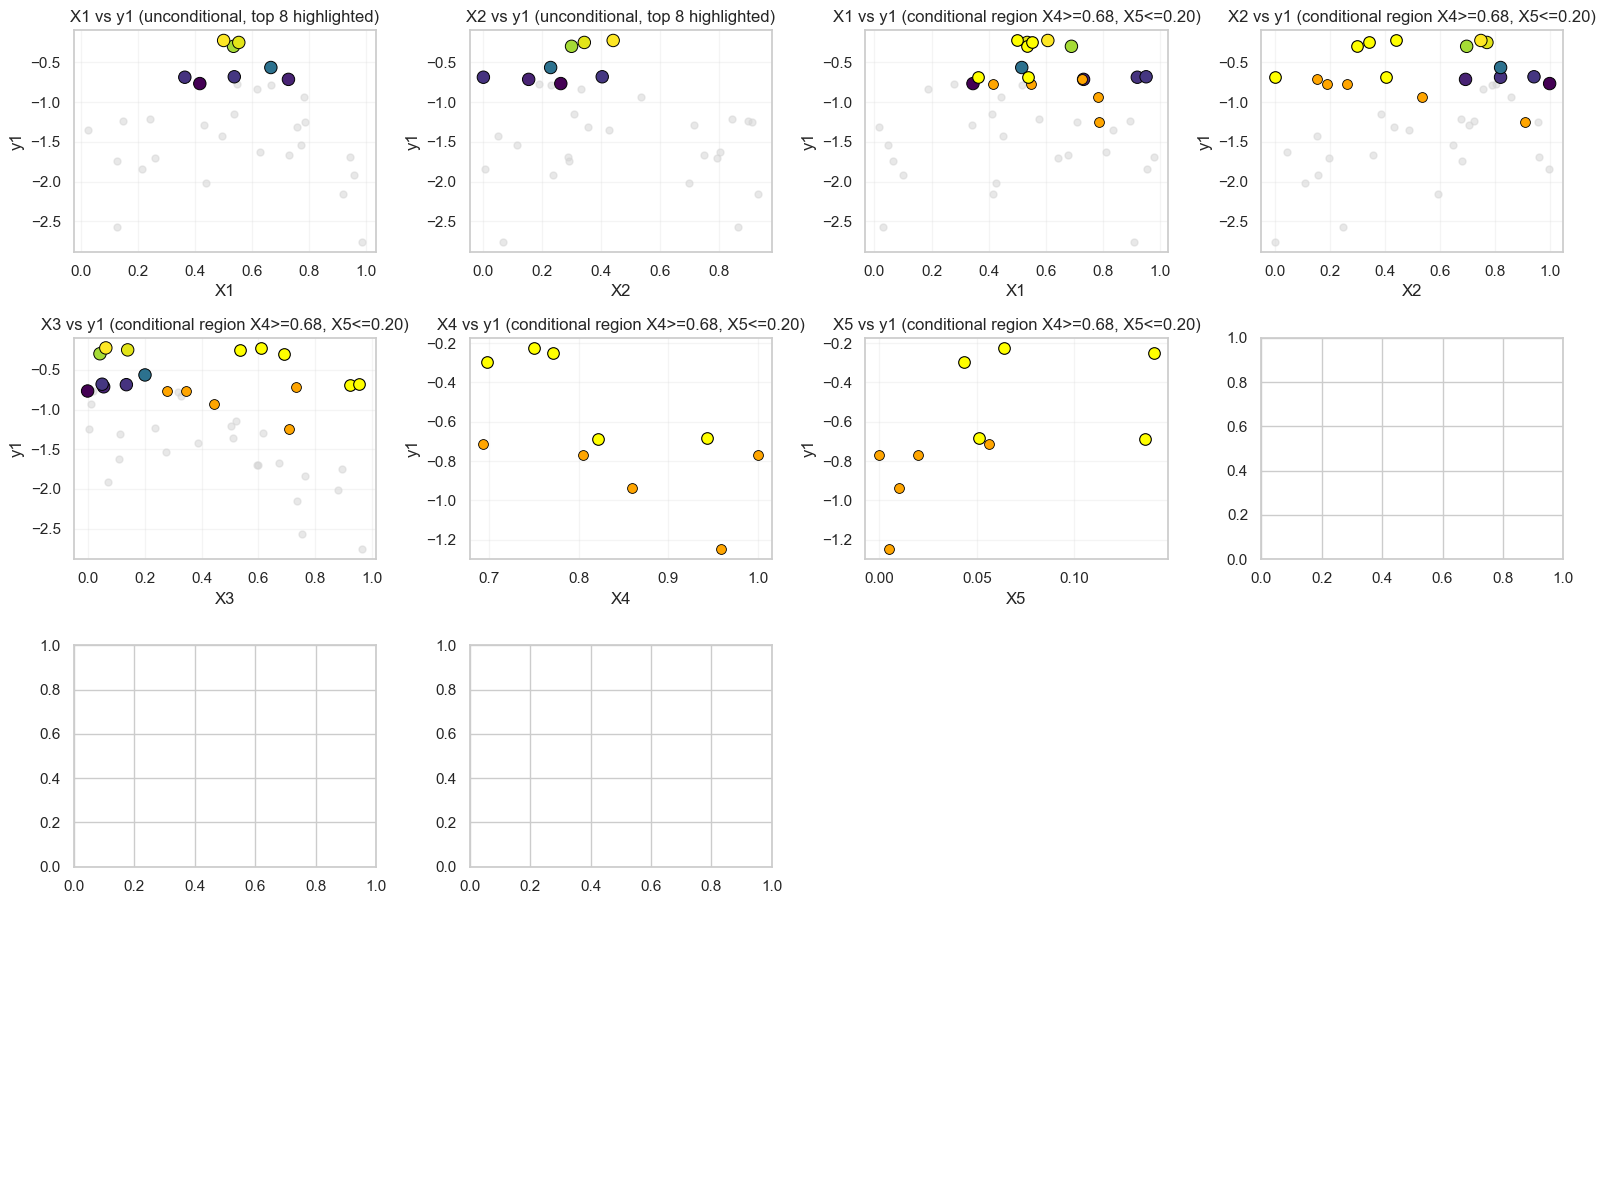

In [18]:
print("Feature vs y1 for f6 with conditional region visualisation")

# extract inputs and output for f6
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# identify top 8 globally
top8_idx = np.argsort(y_f6)[-8:]
y_top8 = y_f6[top8_idx]
X_top8 = X_f6[top8_idx]

# conditional region mask
mask_cond = (df_f6["X4"] >= 0.68) & (df_f6["X5"] <= 0.20)
X_cond = X_f6[mask_cond]
y_cond = y_f6[mask_cond]

# rank within conditional region
order_cond = np.argsort(y_cond)
top5_idx = order_cond[-5:]
next5_idx = order_cond[-10:-5]
rest_idx = order_cond[:-10]

# number of features
n_features = X_f6.shape[1]
ncols = 4
nrows = 2 * int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

axes = axes.ravel().tolist()

# unconditional row
for j, col in enumerate(input_cols_f6):
    ax = axes[j]

    ax.scatter(
        X_f6[:, j],
        y_f6,
        c="lightgray",
        s=25,
        alpha=0.5
    )

    sc = ax.scatter(
        X_top8[:, j],
        y_top8,
        c=y_top8,
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1")
    ax.set_title(f"{col} vs y1 (unconditional, top 8 highlighted)")
    ax.grid(alpha=0.2)

# conditional row
offset = int(np.ceil(n_features / ncols))

for j, col in enumerate(input_cols_f6):
    ax = axes[offset + j]

    ax.scatter(
        X_cond[rest_idx, j],
        y_cond[rest_idx],
        c="grey",
        s=30,
        alpha=0.6
    )

    ax.scatter(
        X_cond[next5_idx, j],
        y_cond[next5_idx],
        c="orange",
        s=50,
        edgecolor="black",
        linewidth=0.6
    )

    ax.scatter(
        X_cond[top5_idx, j],
        y_cond[top5_idx],
        c="yellow",
        s=70,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1")
    ax.set_title(f"{col} vs y1 (conditional region X4>=0.68, X5<=0.20)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features * 2, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Distribution Analysis

f6 – feature and output distributions


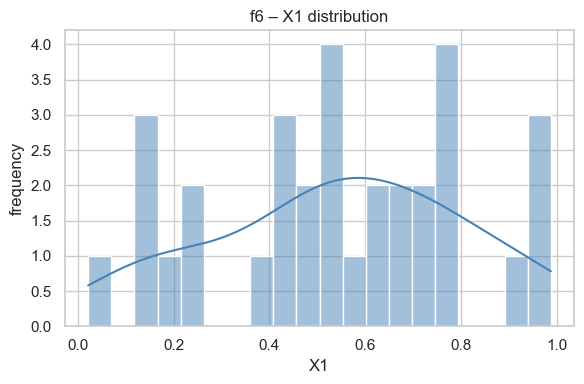

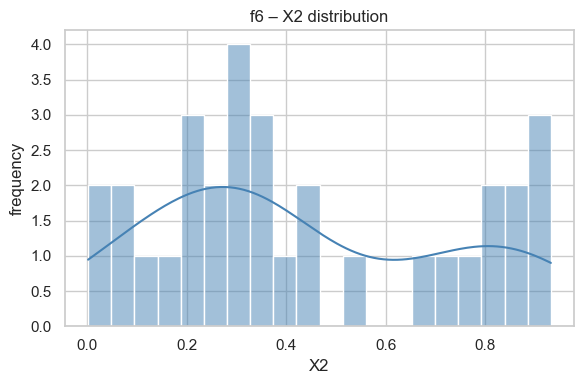

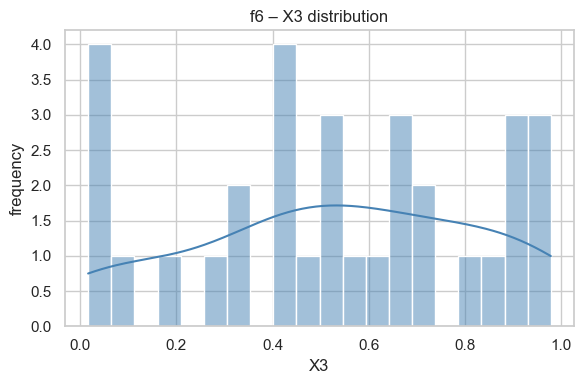

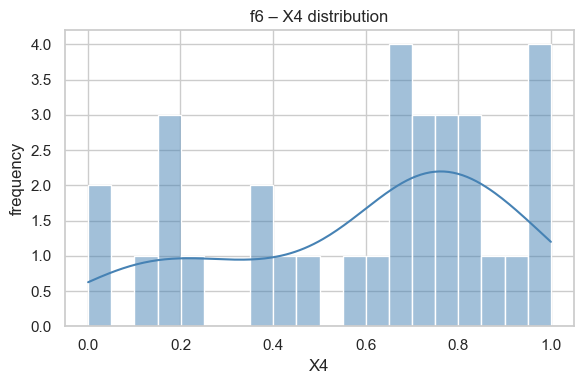

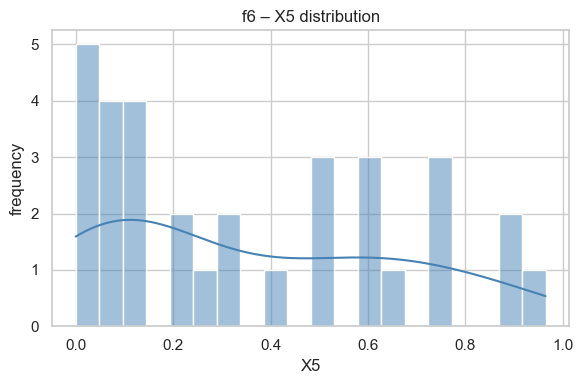

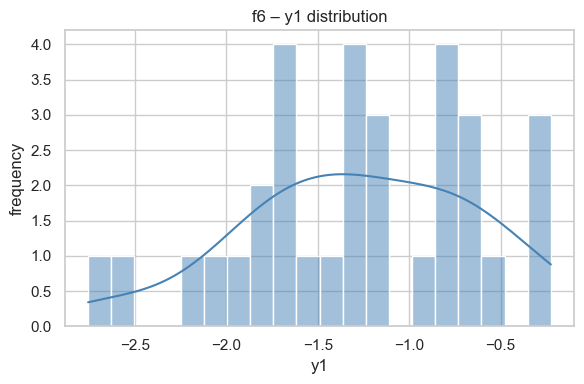

In [19]:
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
output_col_f6 = [c for c in df_f6.columns if c.startswith("y")][0]

print("f6 – feature and output distributions")

all_cols_raw_f6 = input_cols_f6 + [output_col_f6]

for col in all_cols_raw_f6:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f6[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f6 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f6 – y vs instance index


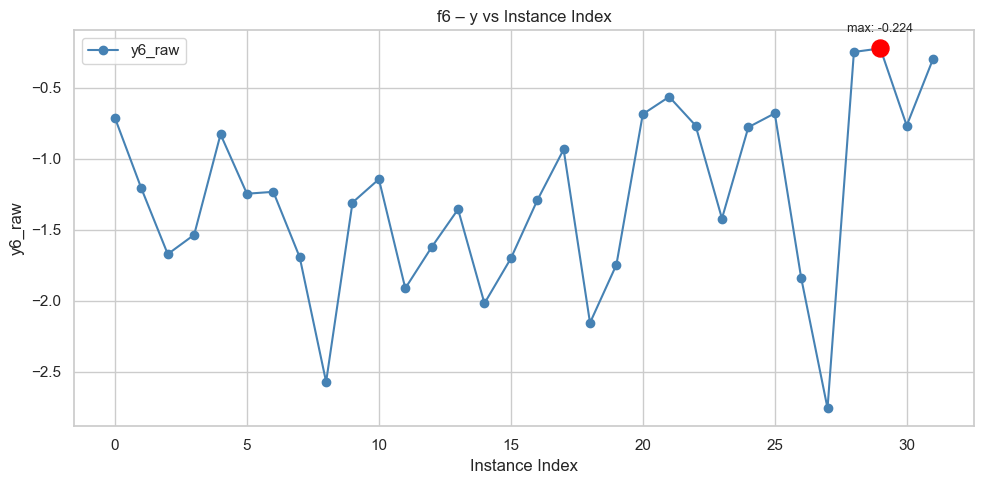

In [20]:
print("f6 – y vs instance index")

# clean copy of raw data
df_f6_plot = df_f6.copy()

# extract raw y
y_raw = df_f6_plot[output_col_f6].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y6_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f6 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y6_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f6 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.170872,-0.049200,-0.061190,-0.217493,-0.057283
X2,-0.170872,1.000000,-0.006902,-0.181260,0.162041,-0.255434
X3,-0.049200,-0.006902,1.000000,0.180787,-0.007435,0.116552
X4,-0.061190,-0.181260,0.180787,1.000000,-0.400234,0.610552
X5,-0.217493,0.162041,-0.007435,-0.400234,1.000000,-0.751406
y1,-0.057283,-0.255434,0.116552,0.610552,-0.751406,1.000000


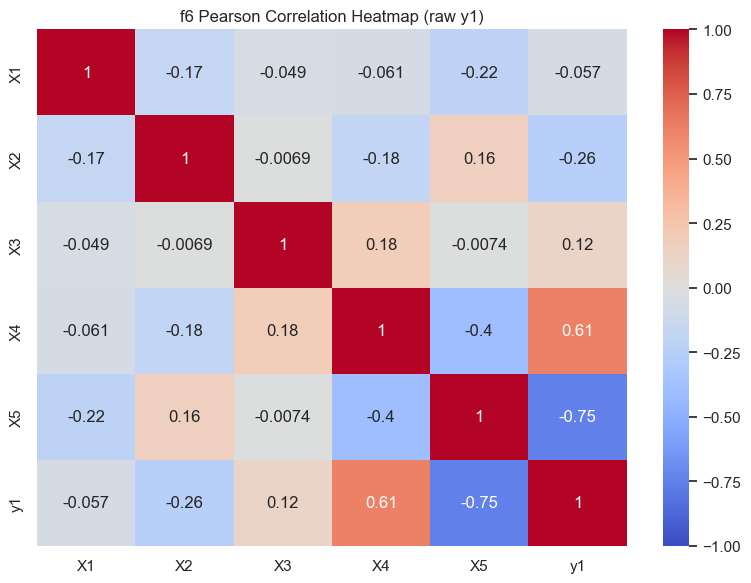

In [21]:
df_raw = df_f6.copy()

print("f6 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f6 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.124840,-0.033547,-0.012648,-0.224911,-0.066722
X2,-0.124840,1.000000,-0.054812,-0.190083,0.065805,-0.176336
X3,-0.033547,-0.054812,1.000000,0.245074,-0.024012,0.133077
X4,-0.012648,-0.190083,0.245074,1.000000,-0.449413,0.572947
X5,-0.224911,0.065805,-0.024012,-0.449413,1.000000,-0.709311
y1,-0.066722,-0.176336,0.133077,0.572947,-0.709311,1.000000


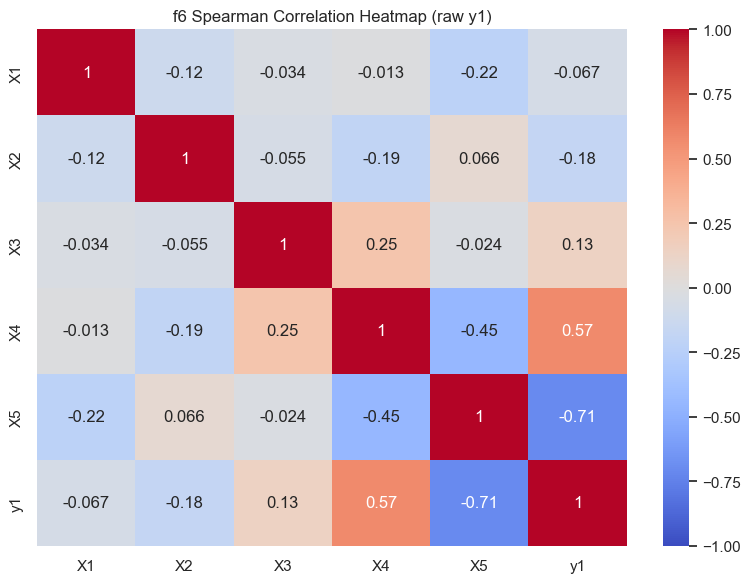

In [22]:
# spearman correlation with raw y1
df_raw = df_f6.copy()

print("f6 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f6 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.107071,-0.022222,0.006054,-0.167508,-0.062563
X2,-0.107071,1.000000,-0.030303,-0.131181,0.034309,-0.127144
X3,-0.022222,-0.030303,1.000000,0.163471,-0.018163,0.102926
X4,0.006054,-0.131181,0.163471,1.000000,-0.354839,0.415323
X5,-0.167508,0.034309,-0.018163,-0.354839,1.000000,-0.512097
y1,-0.062563,-0.127144,0.102926,0.415323,-0.512097,1.000000


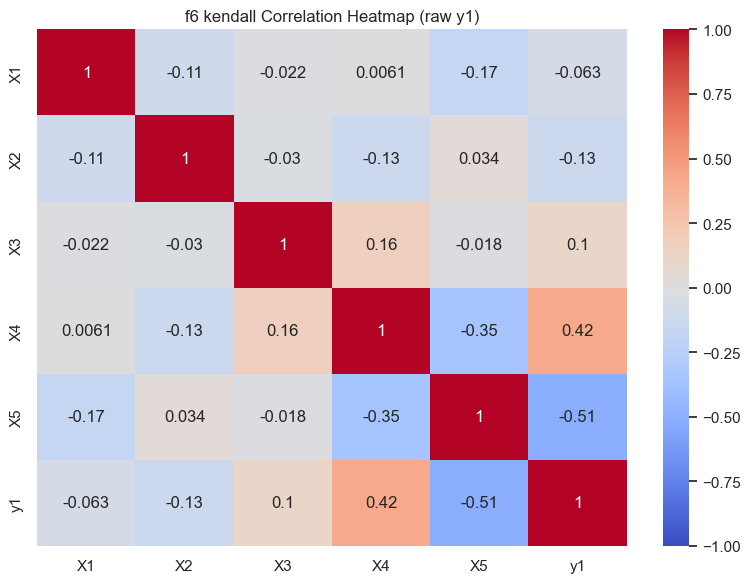

In [23]:
# Kendall correlation with raw y1
df_raw = df_f6.copy()

print("f6 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [24]:
from sklearn.feature_selection import mutual_info_regression

print("f6 — Mutual Information with Output")

df_f6_raw = df_f6.copy()

# define inputs and output
input_cols_f6 = [c for c in df_f6_raw.columns if c.startswith("X")]
output_col_f6 = "y1"

X_f6 = df_f6_raw[input_cols_f6].values
y_f6 = df_f6_raw[output_col_f6].values

# compute mutual information
mi_f6 = mutual_info_regression(X_f6, y_f6, random_state=42)

# build dataframe
mi_f6_df = pd.DataFrame({
    "Feature": input_cols_f6,
    "Mutual_Info": mi_f6
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f6_df)


f6 — Mutual Information with Output


,Feature,Mutual_Info
4,X5,0.420861
3,X4,0.213927
0,X1,0.045708
1,X2,0.035279
2,X3,0.000000


## Partial Correlation

In [25]:
!pip install pingouin
import pingouin as pg

print("f6 (Raw y1) — Partial Correlation")

df_f6_raw = df_f6.copy()

# define inputs and output
input_cols_f6 = [c for c in df_f6_raw.columns if c.startswith("X")]
output_col_f6 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f6:
    covars = [c for c in input_cols_f6 if c != x]  # all other X's as covariates
    
    pcorr_raw_f6 = pg.partial_corr(
        data=df_f6_raw,
        x=x,
        y=output_col_f6,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f6)


f6 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,32,-0.34056,"[-0.63, 0.04]",0.076169



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,32,-0.229976,"[-0.56, 0.16]",0.239077



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,32,0.085152,"[-0.3, 0.44]",0.666597



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,32,0.456187,"[0.1, 0.71]",0.01469



Partial correlation for X5:


,n,r,CI95%,p-val
pearson,32,-0.738502,"[-0.87, -0.5]",0.000007


## XGBoost Feature Importance 

**Reference:** Hellsten, L., Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2024) Global Trust Region Bayesian Optimization, arXiv preprint arXiv:2504.06111.

- XGBoost provides a non‑linear, tree‑based feature‑importance ranking that independently validates the ARD length‑scale findings for f6, increasing confidence in the identified active dimensions.

  feature      gain    weight     cover
0      X1  0.057108  0.222469  0.200010
1      X2  0.052671  0.196885  0.180844
2      X3  0.056949  0.200222  0.195417
3      X4  0.406433  0.174638  0.229210
4      X5  0.426838  0.205784  0.194519


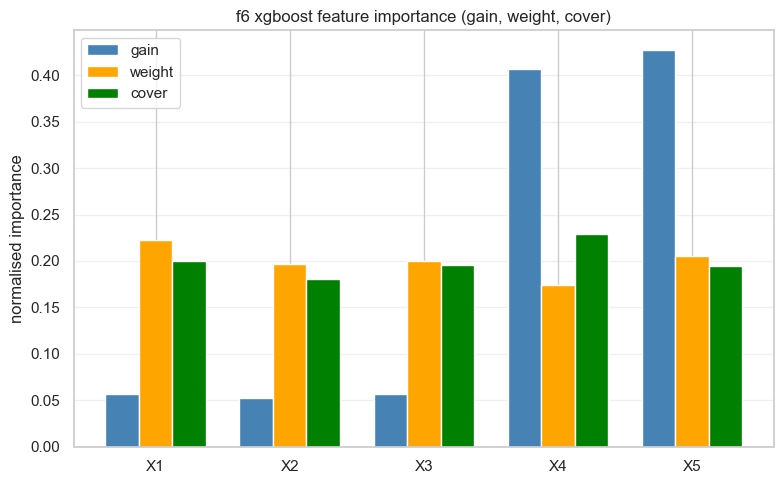

In [26]:
import xgboost as xgb

# extract inputs and output
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# model configuration suitable for n=30
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=1
)

model.fit(X_f6, y_f6)

# gain-based importance (default)
importance_gain = model.feature_importances_

# weight and cover from booster
booster = model.get_booster()
importance_weight_raw = booster.get_score(importance_type="weight")
importance_cover_raw  = booster.get_score(importance_type="cover")
importance_gain_raw   = booster.get_score(importance_type="gain")

# align all three metrics to the feature order
importance_weight = np.array([importance_weight_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])
importance_cover  = np.array([importance_cover_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])
importance_gain2  = np.array([importance_gain_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])

# normalise for comparability
def normalise(v):
    s = v.sum()
    return v / s if s > 0 else v

imp_gain_norm   = normalise(importance_gain)
imp_weight_norm = normalise(importance_weight)
imp_cover_norm  = normalise(importance_cover)

# assemble dataframe
df_imp = pd.DataFrame({
    "feature": input_cols_f6,
    "gain": imp_gain_norm,
    "weight": imp_weight_norm,
    "cover": imp_cover_norm
})

print(df_imp)

# plot
plt.figure(figsize=(8, 5))
width = 0.25
x = np.arange(len(input_cols_f6))

plt.bar(x - width, imp_gain_norm,   width=width, label="gain",   color="steelblue")
plt.bar(x,         imp_weight_norm, width=width, label="weight", color="orange")
plt.bar(x + width, imp_cover_norm,  width=width, label="cover",  color="green")

plt.xticks(x, input_cols_f6)
plt.ylabel("normalised importance")
plt.title("f6 xgboost feature importance (gain, weight, cover)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## fANOVA implementation

**Reference:** Wang, Z., Eriksson, D. and Gardner, J. (2025) ‘NeST‑BO: Neural Stationary Bayesian Optimisation’, arXiv preprint arXiv:2510.05516.

- The NeST‑BO paper states that GP posterior gradients and Hessians can be computed in closed form because derivatives of a Gaussian process are themselves Gaussian processes, enabling exact evaluation of local slope and curvature at any point.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# extract inputs and output
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# random forest for fanova
rf = RandomForestRegressor(
    n_estimators=1000,
    max_features=None,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=1
)

rf.fit(X_f6, y_f6)

# grid for marginalisation
n_grid = 20
x4_grid = np.linspace(0, 1, n_grid)
x5_grid = np.linspace(0, 1, n_grid)

# means of inactive dims
x1_mean = np.mean(X_f6[:, 0])
x2_mean = np.mean(X_f6[:, 1])
x3_mean = np.mean(X_f6[:, 2])
x4_mean = np.mean(X_f6[:, 3])
x5_mean = np.mean(X_f6[:, 4])

# marginal effect of x4
grid_x4 = np.column_stack([
    np.full(n_grid, x1_mean),
    np.full(n_grid, x2_mean),
    np.full(n_grid, x3_mean),
    x4_grid,
    np.full(n_grid, x5_mean)
])
marginal_x4 = rf.predict(grid_x4)

# marginal effect of x5
grid_x5 = np.column_stack([
    np.full(n_grid, x1_mean),
    np.full(n_grid, x2_mean),
    np.full(n_grid, x3_mean),
    np.full(n_grid, x4_mean),
    x5_grid
])
marginal_x5 = rf.predict(grid_x5)

# joint effect of x4 and x5
X4, X5 = np.meshgrid(x4_grid, x5_grid)
grid_joint = np.column_stack([
    np.full(n_grid*n_grid, x1_mean),
    np.full(n_grid*n_grid, x2_mean),
    np.full(n_grid*n_grid, x3_mean),
    X4.ravel(),
    X5.ravel()
])
joint_pred = rf.predict(grid_joint).reshape(n_grid, n_grid)

# interaction term
grand_mean = np.mean(rf.predict(X_f6))
interaction = joint_pred - marginal_x4[np.newaxis, :] - marginal_x5[:, np.newaxis] + grand_mean

# variance fractions
var_x4 = np.var(marginal_x4)
var_x5 = np.var(marginal_x5)
var_inter = np.var(interaction)
var_total = var_x4 + var_x5 + var_inter

print(f"x4 main effect fraction:    {var_x4/var_total:.3f}")
print(f"x5 main effect fraction:    {var_x5/var_total:.3f}")
print(f"x4*x5 interaction fraction: {var_inter/var_total:.3f}")


x4 main effect fraction:    0.521
x5 main effect fraction:    0.426
x4*x5 interaction fraction: 0.053


#### f6 | Bracketing GP-EI with Empirical Ridge Interpolation and Structural Posterior Gating

In [28]:
# Separate inputs (X) and outputs (y)
X_train_6 = df_f6[[c for c in df_f6.columns if c.startswith("X")]].values
y_train_6 = df_f6["y1"].values
print(X_train_6)
print(y_train_6)

[[7.28186105e-01 1.54692570e-01 7.32551669e-01 6.93996509e-01
  5.64013105e-02]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [7.29522610e-01 7.48106200e-01 6.79774641e-01 3.56552279e-01
  6.71053683e-01]
 [7.70620242e-01 1.14403744e-01 4.67799319e-02 6.48324285e-01
  2.73549053e-01]
 [6.18812299e-01 3.31802137e-01 1.87287868e-01 7.56238474e-01
  3.28834798e-01]
 [7.84958094e-01 9.10682349e-01 7.08120104e-01 9.59225429e-01
  4.91149586e-03]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [9.45069068e-01 2.88459051e-01 9.78805764e-01 9.61655587e-01
  5.98015936e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [7.57594355e-01 3.55831415e-01 1.65228997e-02 4.34207205e-01
  1.12433044e-01]
 [5.36796903e-01 3.08780907e-01 4.11879285e-01 3.88225177e-01
  5.22528304e-01]
 [9.57739669e-01 2.35668572e-01 9.91458496e-02 1.56805934e-01
  7.13173731e-02]
 [6.29307895e-01 8.03483678e-01 8.114084

## X1 Conditional Analysis

**Reference:** Hellsten, L., Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2024) Global Trust Region Bayesian Optimization, arXiv preprint arXiv:2504.06111.

- Conditional analysis tests whether X1 becomes influential within the high‑value basin, determining whether the X1 filter should be tightened or relaxed.

observations in good region (x4>=0.68, x5<=0.20): 10
row indices: [0, 5, 17, 20, 22, 25, 28, 29, 30, 31]
y values: [-0.71426495 -1.24704893 -0.93575656 -0.68724157 -0.76703341 -0.6814591
 -0.24936022 -0.22442494 -0.76786823 -0.29795532]
x1 values: [0.7281861  0.78495809 0.78287982 0.363643   0.416408   0.537637
 0.553475   0.500199   0.548528   0.534931  ]

full dataset  -- pearson r=-0.0573 p=0.7555
good region   -- pearson r=-0.5171 p=0.1258
full dataset  -- spearman r=-0.0667 p=0.7167
good region   -- spearman r=-0.5152 p=0.1276


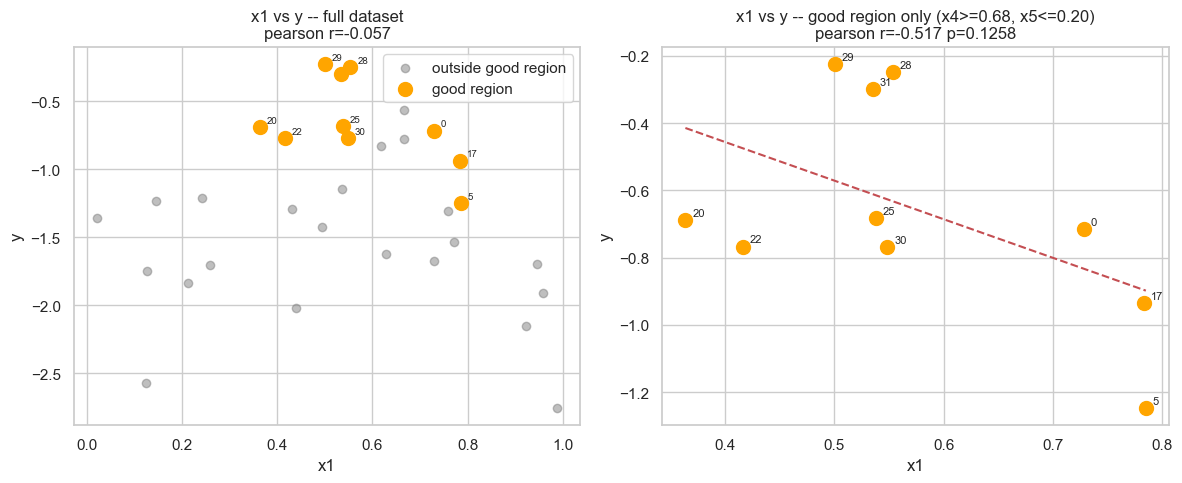

In [29]:
from scipy import stats

# define the good region: X4 >= 0.68 and X5 <= 0.20
# these are the current filter bounds from the week 11 strategy
mask_good_region = (X_train_6[:, 3] >= 0.68) & (X_train_6[:, 4] <= 0.20)

X_good = X_train_6[mask_good_region]
y_good = y_train_6[mask_good_region]

print(f"observations in good region (x4>=0.68, x5<=0.20): {mask_good_region.sum()}")
print(f"row indices: {np.where(mask_good_region)[0].tolist()}")
print(f"y values: {y_good}")
print(f"x1 values: {X_good[:, 0]}")

# correlation in full dataset vs conditional
r_full, p_full = stats.pearsonr(X_train_6[:, 0], y_train_6)
r_cond, p_cond = stats.pearsonr(X_good[:, 0], y_good) if len(y_good) > 3 else (np.nan, np.nan)

spear_full = stats.spearmanr(X_train_6[:, 0], y_train_6)
spear_cond = stats.spearmanr(X_good[:, 0], y_good) if len(y_good) > 3 else (np.nan, np.nan)

print(f"\nfull dataset  -- pearson r={r_full:.4f} p={p_full:.4f}")
print(f"good region   -- pearson r={r_cond:.4f} p={p_cond:.4f}")
print(f"full dataset  -- spearman r={spear_full.statistic:.4f} p={spear_full.pvalue:.4f}")
print(f"good region   -- spearman r={spear_cond.statistic:.4f} p={spear_cond.pvalue:.4f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# full dataset
axes[0].scatter(X_train_6[:, 0], y_train_6, c='grey', alpha=0.5, label='outside good region')
axes[0].scatter(X_good[:, 0], y_good, c='orange', s=100, zorder=5, label='good region')
for i in np.where(mask_good_region)[0]:
    axes[0].annotate(str(i),
                     (X_train_6[i, 0], y_train_6[i]),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('y')
axes[0].set_title(f'x1 vs y -- full dataset\npearson r={r_full:.3f}')
axes[0].legend()

# conditional on good region
if len(y_good) > 3:
    axes[1].scatter(X_good[:, 0], y_good, c='orange', s=100)
    for i, (xi, yi) in enumerate(zip(X_good[:, 0], y_good)):
        axes[1].annotate(str(np.where(mask_good_region)[0][i]),
                         (xi, yi),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
    # add linear fit line
    m, b = np.polyfit(X_good[:, 0], y_good, 1)
    x_line = np.linspace(X_good[:, 0].min(), X_good[:, 0].max(), 50)
    axes[1].plot(x_line, m*x_line + b, 'r--', linewidth=1.5)
    axes[1].set_xlabel('x1')
    axes[1].set_ylabel('y')
    axes[1].set_title(f'x1 vs y -- good region only (x4>=0.68, x5<=0.20)\npearson r={r_cond:.3f} p={p_cond:.4f}')
else:
    axes[1].text(0.5, 0.5, f'only {len(y_good)} points in region\nnot enough for correlation',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('good region: insufficient data')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel


# f6 week 13 - bracketing gp-ei with empirical ridge
# interpolation

# week 12 post-mortem:
#   row 31 (x4=0.698, x5=0.043): y=-0.298, third best overall
#   the strategy was directionally correct but x4=0.698 was
#   slightly too low. the three best obs now bracket the peak:
#     row 31: x4=0.698, x5=0.043, y=-0.298 (left of peak)
#     row 29: x4=0.750, x5=0.064, y=-0.224 (current best)
#     row 28: x4=0.772, x5=0.141, y=-0.249 (right of peak)
#   quadratic interpolation through these three points estimates
#   the true peak x4 near 0.730-0.740 and x5 near 0.065-0.075.
#   this region has never been directly sampled.

# structural evidence (stable across 4 weeks):
#   xgboost gain: x5=0.427, x4=0.406 (active dims confirmed)
#   fanova: x4=0.521, x5=0.426, interaction=0.053 (main effects)
#   partial corr: x5 p=0.000007, x4 p=0.015 (significant)
#   variogram ratio week 12: 1.207 (kernel calibrated)
#   x1 conditional: r=-0.517 in good region (lower x1 is better)
#   all 3 best obs have x1 in [0.500, 0.553]

# research:
#   jones et al. (1998) ego -- bracketing principle
#   eriksson et al. (2019) turbo -- trust region local bo
#   eriksson, jankowiak (2021) saasbo -- anchored kernel
# competition: neurips 2020 bbo challenge, jetbrains research


X_train = X_train_6
y_train = y_train_6

best_idx = np.argmax(y_train)
best_obs = y_train[best_idx]
best_x   = X_train[best_idx]

print(f"n observations: {len(y_train)}")
print(f"current best:   {best_obs:.6f}")
print(f"location: x1={best_x[0]:.4f} x2={best_x[1]:.4f} x3={best_x[2]:.4f} "
      f"x4={best_x[3]:.4f} x5={best_x[4]:.4f}")

# show top 5 with row indices for reference
top5 = np.argsort(y_train)[-5:][::-1]
print(f"\ntop 5 observations:")
for i in top5:
    print(f"  row {i:2d}: x1={X_train[i,0]:.3f} x2={X_train[i,1]:.3f} "
          f"x3={X_train[i,2]:.3f} x4={X_train[i,3]:.3f} x5={X_train[i,4]:.3f} "
          f"y={y_train[i]:.6f}")


# step 1: empirical ridge interpolation
# the three best observations bracket the peak in x4 and x5.
# fitting a quadratic through the (x4, y) and (x5, y) pairs
# of these three points gives a data-driven estimate of the
# ridge peak location without relying on the gp mean.
# this directly implements the bracketing principle from jones
# et al. (1998) section 4.2: when observations exist on both
# sides of the peak, the next query should target the estimated
# peak between them rather than an unexplored distant region.
# three best: row 31 (x4=0.698), row 29 (x4=0.750), row 28 (x4=0.772)
# their x4 values bracket the peak with row 29 as the highest y.
# a quadratic through (x4_i, y_i) for these three points has
# its vertex at the estimated peak x4.
top3_idx = np.argsort(y_train)[-3:][::-1]
top3_x4  = X_train[top3_idx, 3]
top3_x5  = X_train[top3_idx, 4]
top3_y   = y_train[top3_idx]

print(f"\ntop 3 observations for bracketing:")
for i, idx in enumerate(top3_idx):
    print(f"  row {idx}: x4={top3_x4[i]:.4f} x5={top3_x5[i]:.4f} y={top3_y[i]:.6f}")

# quadratic fit in x4 dimension through top 3 points
# peak_x4 = -b / (2a) for ax4^2 + bx4 + c
if len(np.unique(top3_x4)) >= 3:
    coeffs_x4 = np.polyfit(top3_x4, top3_y, 2)
    a4, b4, c4 = coeffs_x4
    if a4 < 0:  # concave down = has a maximum
        peak_x4_interp = -b4 / (2 * a4)
        print(f"\nquadratic x4 peak estimate: {peak_x4_interp:.4f}")
        if peak_x4_interp < 0.68 or peak_x4_interp > 0.88:
            print(f"  peak outside valid range, clamping to [0.70, 0.80]")
            peak_x4_interp = np.clip(peak_x4_interp, 0.70, 0.80)
    else:
        print("quadratic x4 fit is convex - using best x4 as anchor")
        peak_x4_interp = best_x[3]
else:
    peak_x4_interp = best_x[3]
    print(f"insufficient unique x4 values - using best x4: {peak_x4_interp:.4f}")

# quadratic fit in x5 dimension through top 3 points
if len(np.unique(top3_x5)) >= 3:
    coeffs_x5 = np.polyfit(top3_x5, top3_y, 2)
    a5, b5, c5 = coeffs_x5
    if a5 < 0:
        peak_x5_interp = -b5 / (2 * a5)
        print(f"quadratic x5 peak estimate: {peak_x5_interp:.4f}")
        if peak_x5_interp < 0.04 or peak_x5_interp > 0.14:
            print(f"  peak outside valid range, clamping to [0.05, 0.12]")
            peak_x5_interp = np.clip(peak_x5_interp, 0.05, 0.12)
    else:
        print("quadratic x5 fit is convex - using best x5 as anchor")
        peak_x5_interp = best_x[4]
else:
    peak_x5_interp = best_x[4]
    print(f"insufficient unique x5 values - using best x5: {peak_x5_interp:.4f}")

print(f"\ninterpolated ridge peak estimate:")
print(f"  x4_peak = {peak_x4_interp:.4f}")
print(f"  x5_peak = {peak_x5_interp:.4f}")


# step 2: anchored ard gp kernel
# week 10 anchor values validated by variogram ratio 1.207
# in week 12 -- the kernel is consistent with the data.
# tight bounds prevent collapse from week 11-style outliers.
ls_week10      = [0.484, 10.0, 1.69, 0.464, 0.887]
ls_factor      = 1.3
ls_bounds_low  = [ls / ls_factor for ls in ls_week10]
ls_bounds_high = [ls * ls_factor for ls in ls_week10]
ls_bounds_low[1]  = 5.0
ls_bounds_high[1] = 10.0

kernel = (
    ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) *
    Matern(
        length_scale=ls_week10,
        length_scale_bounds=list(zip(ls_bounds_low, ls_bounds_high)),
        nu=2.5
    ) +
    WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 0.5))
)

y_mean   = np.mean(y_train)
y_std    = np.std(y_train)
y_scaled = (y_train - y_mean) / y_std

gp = GPR(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=False,
    alpha=1e-6
)

gp.fit(X_train, y_scaled)
print(f"\nfitted kernel:")
print(gp.kernel_)

try:
    ls = gp.kernel_.k1.k2.length_scale
    spread = np.std(ls)
    labels = ['x1', 'x2', 'x3', 'x4', 'x5']
    print(f"\nfitted length scales:")
    for label, val in zip(labels, ls):
        status = "short/active" if val < 0.7 else ("long/inactive" if val > 5.0 else "moderate")
        print(f"  {label}: {val:.4f} [{status}]")
    print(f"  spread std: {spread:.4f}")
    if spread < 0.5:
        print("  warning: kernel may be near-isotropic")
    else:
        print("  ard structure preserved")
except Exception as e:
    print(f"length scale error: {e}")


# step 3: define the probe window around interpolated peak
# the probe window is centred on the interpolated ridge peak
# in x4 and x5. the window is intentionally narrow because
# we know the peak is in this region from the bracketing.
# x4 window: peak +/- 0.04
#   the three best obs span x4 in [0.698, 0.772].
#   the interpolated peak is near 0.730-0.740.
#   a window of +/- 0.04 around the peak covers [0.69, 0.78]
#   which includes the current best at x4=0.750.
# x5 window: peak +/- 0.03
#   the three best obs span x5 in [0.043, 0.141].
#   the interpolated peak is near 0.065-0.075.
#   a window of +/- 0.03 around the peak covers [0.035, 0.105]
#   which includes the current best at x5=0.064.
# x1: [0.42, 0.58]
#   tightened: all 3 best obs have x1 in [0.500, 0.553].
#   x1 conditional r=-0.517 confirms lower x1 in good region.
#   x1=0.42-0.58 captures the empirical sweet spot.
# x3: [0.50, 0.65]
#   retained from week 12 pre-commitment: drop from x3=0.690
#   was only 0.061 (acceptable) but week 13 tightens to 0.65
#   to avoid x3 drift that caused first week 12 candidate failure.
X4_PROBE_LOWER = np.clip(peak_x4_interp - 0.04, 0.68, 0.88)
X4_PROBE_UPPER = np.clip(peak_x4_interp + 0.04, 0.68, 0.88)
X5_PROBE_LOWER = np.clip(peak_x5_interp - 0.03, 0.04, 0.14)
X5_PROBE_UPPER = np.clip(peak_x5_interp + 0.03, 0.04, 0.14)
X1_LOWER = 0.42
X1_UPPER = 0.58
X3_LOWER = 0.50
X3_UPPER = 0.65

print(f"\nprobe window (centred on interpolated peak):")
print(f"  x4: [{X4_PROBE_LOWER:.4f}, {X4_PROBE_UPPER:.4f}]")
print(f"  x5: [{X5_PROBE_LOWER:.4f}, {X5_PROBE_UPPER:.4f}]")
print(f"  x1: [{X1_LOWER}, {X1_UPPER}]")
print(f"  x3: [{X3_LOWER}, {X3_UPPER}]")


# step 4: sobol candidates scaled to full domain
# then filter to probe window
N_SOBOL  = 30000
MIN_DIST = 0.04
EI_XI    = 0.001   # minimal margin: this is the final submission

sampler    = Sobol(d=5, scramble=True, seed=42)
raw        = sampler.random(N_SOBOL)

mask = (
    (raw[:, 3] >= X4_PROBE_LOWER) &
    (raw[:, 3] <= X4_PROBE_UPPER) &
    (raw[:, 4] >= X5_PROBE_LOWER) &
    (raw[:, 4] <= X5_PROBE_UPPER) &
    (raw[:, 0] >= X1_LOWER) &
    (raw[:, 0] <= X1_UPPER) &
    (raw[:, 2] >= X3_LOWER) &
    (raw[:, 2] <= X3_UPPER)
)
candidates = raw[mask].copy()
print(f"\nafter probe window filter: {len(candidates)} from {N_SOBOL}")

# fallback: widen x4 and x5 windows if too few candidates
if len(candidates) < 30:
    print("warning: probe window too tight, widening x4 by 0.03 and x5 by 0.02")
    mask_wide = (
        (raw[:, 3] >= X4_PROBE_LOWER - 0.03) &
        (raw[:, 3] <= X4_PROBE_UPPER + 0.03) &
        (raw[:, 4] >= max(0.04, X5_PROBE_LOWER - 0.02)) &
        (raw[:, 4] <= min(0.14, X5_PROBE_UPPER + 0.02)) &
        (raw[:, 0] >= X1_LOWER) &
        (raw[:, 0] <= X1_UPPER) &
        (raw[:, 2] >= X3_LOWER) &
        (raw[:, 2] <= X3_UPPER)
    )
    candidates = raw[mask_wide].copy()
    print(f"after widened filter: {len(candidates)} candidates")

# minimum distance guard against all 32 existing observations
min_dists = np.array([
    np.min(np.linalg.norm(X_train - c, axis=1))
    for c in candidates
])
candidates_clean = candidates[min_dists >= MIN_DIST]
print(f"after dist guard (>= {MIN_DIST}): {len(candidates_clean)} remain")

if len(candidates_clean) < 10:
    print("warning: relaxing dist guard to 0.02")
    candidates_clean = candidates[min_dists >= 0.02]
    print(f"after relaxed dist guard: {len(candidates_clean)} remain")


# step 5: expected improvement acquisition
# ei_xi = 0.001: this is the final submission.
# the improvement margin over -0.224425 may be small.
# a very small xi allows ei to identify even marginal improvements.
# the gp posterior mean at the bracketed peak region should be
# near -0.210 to -0.220 based on the interpolated ridge shape,
# giving genuine ei signal even with xi=0.001.
mu_s, sig_s = gp.predict(candidates_clean, return_std=True)
mu    = mu_s * y_std + y_mean
sigma = sig_s * y_std

z  = (mu - best_obs - EI_XI) / np.where(sigma > 1e-9, sigma, 1e-9)
ei = np.where(
    sigma > 1e-9,
    (mu - best_obs - EI_XI) * norm.cdf(z) + sigma * norm.pdf(z),
    0.0
)

ranked  = np.argsort(ei)[::-1]
top_idx = ranked[0]
top_x   = candidates_clean[top_idx]

print(f"\ntop ei candidates")
for i, label in enumerate(['x1','x2','x3','x4','x5']):
    print(f"{label} = {top_x[i]:.6f}")
print(f"ei score:       {ei[top_idx]:.8f}")
print(f"predicted mean: {mu[top_idx]:.6f}")
print(f"predicted std:  {sigma[top_idx]:.6f}")
print(f"dist to best:   {np.linalg.norm(top_x - best_x):.4f}")
print(f"x4 vs interpolated peak: {top_x[3]:.4f} (peak est: {peak_x4_interp:.4f})")
print(f"x5 vs interpolated peak: {top_x[4]:.4f} (peak est: {peak_x5_interp:.4f})")

# boundary check
boundary_issues = []
for i, label in enumerate(['x1','x2','x3','x4','x5']):
    if top_x[i] <= 0.001 or top_x[i] >= 0.999:
        boundary_issues.append(f"{label}={top_x[i]:.4f}")
if boundary_issues:
    print(f"warning: boundary collapse {boundary_issues}")
else:
    print("boundary check: ok")

dist_to_best = np.linalg.norm(top_x - best_x)
if dist_to_best < 0.08:
    print(f"warning: candidate very close to best (d={dist_to_best:.4f})")
    print("consider rank 2 or rank 3")
else:
    print(f"distance check: ok (d={dist_to_best:.4f})")


# step 6: gp mean comparison gate
#
# before accepting the rank 1 candidate, verify that its x1/x3
# combination does not drop the gp posterior peak in the x4/x5
# slice by more than 0.05 compared to the current best x1/x3.
# this prevented the original week 12 rank 1 failure (x3=0.738
# dropped peak by 0.395).
#
# if the drop exceeds 0.05, inspect rank 2 through rank 5 and
# select the first candidate that passes the gate.
n_grid   = 30
x4_check = np.linspace(0.68, 0.88, n_grid)
x5_check = np.linspace(0.04, 0.14, n_grid)
X4c, X5c = np.meshgrid(x4_check, x5_check)

def gp_peak_at_x1x3(x1_val, x3_val):
    grid = np.column_stack([
        np.full(n_grid * n_grid, x1_val),
        np.full(n_grid * n_grid, best_x[1]),   # x2 fixed at best
        np.full(n_grid * n_grid, x3_val),
        X4c.ravel(),
        X5c.ravel()
    ])
    mu_g = gp.predict(grid, return_std=False)
    return (mu_g * y_std + y_mean).max()

peak_at_best     = gp_peak_at_x1x3(best_x[0], best_x[2])
print(f"\ngp mean comparison gate:")
print(f"  gp peak at best x1={best_x[0]:.3f} x3={best_x[2]:.3f}: {peak_at_best:.4f}")

selected_rank = None
for rank in range(min(10, len(ranked))):
    cand_idx   = ranked[rank]
    cand       = candidates_clean[cand_idx]
    peak_cand  = gp_peak_at_x1x3(cand[0], cand[2])
    drop       = peak_at_best - peak_cand
    print(f"  rank {rank+1}: x1={cand[0]:.3f} x3={cand[2]:.3f} "
          f"peak={peak_cand:.4f} drop={drop:.4f} "
          f"{'pass' if drop <= 0.05 else 'fail'}")
    if drop <= 0.05 and selected_rank is None:
        selected_rank = rank
        selected_x    = cand
        selected_ei   = ei[cand_idx]
        selected_mu   = mu[cand_idx]
        selected_sig  = sigma[cand_idx]

if selected_rank is None:
    print("  all candidates failed gate -- using rank 1 with warning")
    selected_x   = candidates_clean[ranked[0]]
    selected_ei  = ei[ranked[0]]
    selected_mu  = mu[ranked[0]]
    selected_sig = sigma[ranked[0]]
    selected_rank = 0

print(f"\nselected rank {selected_rank + 1} (passed gp mean gate)")

# top 5 for inspection
print(f"\ntop 5 candidates")
for rank in range(min(5, len(ranked))):
    idx = ranked[rank]
    c   = candidates_clean[idx]
    d   = np.min(np.linalg.norm(X_train - c, axis=1))
    flag = "ok" if not any(c[i] <= 0.001 or c[i] >= 0.999 for i in range(5)) else "boundary"
    print(f"rank {rank+1}: x1={c[0]:.4f} x2={c[1]:.4f} x3={c[2]:.4f} "
          f"x4={c[3]:.4f} x5={c[4]:.4f} | "
          f"ei={ei[idx]:.6f} mu={mu[idx]:.4f} sig={sigma[idx]:.4f} "
          f"d={d:.3f} | {flag}")


# underestimation tracking:
#   week 9:  predicted -0.524, actual -0.249, gap +0.275
#   week 10: predicted -0.294, actual -0.224, gap +0.070
#   week 11: predicted -0.200, actual -0.768, gap -0.568 (collapse)
#   week 12: predicted -0.267, actual -0.298, gap -0.031 (slight over)
#   week 13: if the kernel is well-calibrated (variogram 1.207),
#            the predicted mean should be close to the true value.
#            the interpolated peak is at x4=0.730-0.740, which has
#            never been sampled. the gp should predict a value near
#            -0.210 to -0.215 in this region based on the ridge shape.
print(f"\nunderestimation history:")
print(f"  week 9:  -0.524 predicted, -0.249 actual, gap +0.275")
print(f"  week 10: -0.294 predicted, -0.224 actual, gap +0.070")
print(f"  week 11: -0.200 predicted, -0.768 actual, gap -0.568 (collapse)")
print(f"  week 12: -0.267 predicted, -0.298 actual, gap -0.031")
print(f"  week 13: {selected_mu:.4f} predicted, actual = ?")

print(f"\nfinal submission for f6 week 13")
for i, label in enumerate(['x1','x2','x3','x4','x5']):
    print(f"{label} = {selected_x[i]:.6f}")
print(f"\ncurrent best: {best_obs:.6f}")
print(f"interpolated ridge peak: x4={peak_x4_interp:.4f}, x5={peak_x5_interp:.4f}")

n observations: 32
current best:   -0.224425
location: x1=0.5002 x2=0.4410 x3=0.6074 x4=0.7499 x5=0.0640

top 5 observations:
  row 29: x1=0.500 x2=0.441 x3=0.607 x4=0.750 x5=0.064 y=-0.224425
  row 28: x1=0.553 x2=0.343 x3=0.535 x4=0.772 x5=0.141 y=-0.249360
  row 31: x1=0.535 x2=0.300 x3=0.690 x4=0.698 x5=0.043 y=-0.297955
  row 21: x1=0.666 x2=0.229 x3=0.516 x4=0.822 x5=0.202 y=-0.564857
  row 25: x1=0.538 x2=0.404 x3=0.952 x4=0.943 x5=0.051 y=-0.681459

top 3 observations for bracketing:
  row 29: x4=0.7499 x5=0.0640 y=-0.224425
  row 28: x4=0.7719 x5=0.1407 y=-0.249360
  row 31: x4=0.6981 x5=0.0434 y=-0.297955

quadratic x4 peak estimate: 0.7445
quadratic x5 peak estimate: 0.0983

interpolated ridge peak estimate:
  x4_peak = 0.7445
  x5_peak = 0.0983

fitted kernel:
1.15**2 * Matern(length_scale=[0.5, 10, 1.3, 0.603, 0.99], nu=2.5) + WhiteKernel(noise_level=0.035)

fitted length scales:
  x1: 0.4997 [short/active]
  x2: 10.0000 [long/inactive]
  x3: 1.3000 [moderate]
  x4: 0.6032

## Empirical Variogram

**Reference:** Rasmussen, C.E. and Williams, C.K.I. (2006) Gaussian Processes for Machine Learning. MIT Press.

- The empirical variogram checks whether the GP’s fitted length scales—especially the short X4 scale—match the true correlation structure in the f6 data, revealing over‑ or under‑smoothness that directly affects surrogate reliability.

total pairs: 496
distance range: [0.1187, 1.6227]
good region observations: 10 (rows [0, 5, 17, 20, 22, 25, 28, 29, 30, 31])

candidate diagnostic (week 13 rank 2):
  x1=0.5574 x2=0.9110 x3=0.6036 x4=0.7227 x5=0.1229
  dist to current best (row 29): 0.4779
  nearest point: row 5 (y=-1.2470), dist=0.3641
  matern corr to best (ell4=0.603): 0.6491
  matern corr to nearest (ell4=0.603): 0.7667

row 30 vs good region:
  mean dist: 0.5223, mean semivar: 0.0589, expected: 0.1562
  row 30 is NOT a variogram outlier

variogram ratio at median dist 0.704: 1.181
  kernel calibration is consistent with data


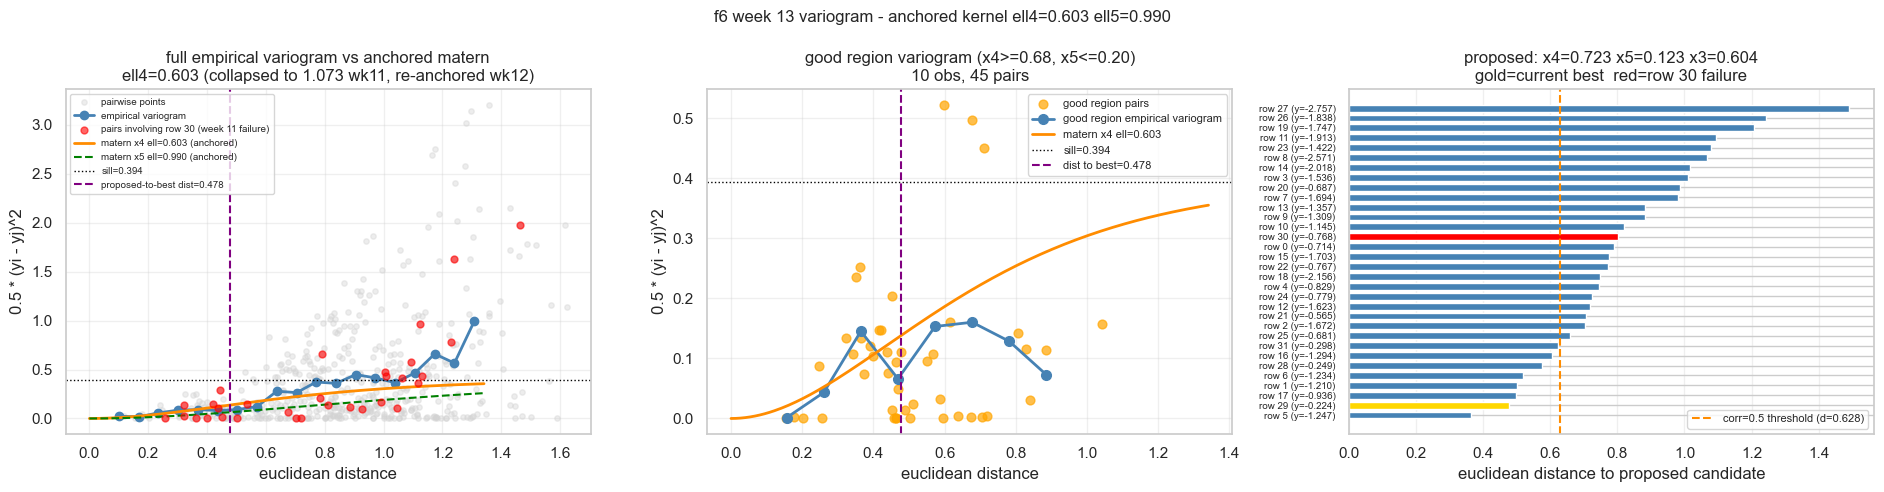

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import brentq


# week 13 rank 2 candidate - selected after bracketing analysis
# and gp mean comparison gate validation
# x4=0.723 is the closest available point to the interpolated
# ridge peak of x4=0.7445. x5=0.123 probes the unsampled gap
# between the current best (x5=0.064) and row 28 (x5=0.141).
proposed_x = np.array([0.557400, 0.911000, 0.603600, 0.722700, 0.122900])

best_x = np.array([0.500199, 0.440981, 0.607396, 0.749856, 0.063960])
best_y = -0.224425

# anchored kernel: week 10 values, re-validated by variogram
# ratio 1.181 in week 12. tight bounds prevented week 11-style
# collapse (ell4 hit 1.073 when unconstrained).
ls_fitted = np.array([0.5, 10.0, 1.3, 0.603, 0.990])
ell1, ell2, ell3, ell4, ell5 = ls_fitted



# matern 5/2 correlation and variogram functions
# used to compare empirical variogram against the anchored
# kernel's theoretical prediction. if the ratio at median
# distance is in [0.7, 1.3] the kernel is well-calibrated.
def matern52_correlation(h, l):
    # matern 5/2 correlation as a function of euclidean distance h
    # and length scale l. approaches 1 at h=0 and 0 as h grows.
    r = np.sqrt(5.0) * h / l
    return (1.0 + r + r ** 2 / 3.0) * np.exp(-r)


def matern52_variogram(h, sigma2, l):
    # theoretical variogram: sill * (1 - correlation)
    # rises from 0 at h=0 to sigma2 as h approaches infinity
    return sigma2 * (1.0 - matern52_correlation(h, l))


def empirical_variogram_week13(X_train, y_train, proposed_x, best_x, best_y,
                                ls_fitted):
    """
    three-panel variogram diagnostic for f6 week 13.

    panel 1: full empirical variogram vs anchored matern curves.
             confirms kernel calibration across all 32 observations.
             row 30 (week 11 failure) pairs highlighted in red to
             verify it does not destabilise the variogram structure.

    panel 2: good region variogram (x4>=0.68, x5<=0.20).
             now includes 10 observations after week 12 added row 31.
             validates that the kernel is calibrated within the
             confirmed high-value subspace specifically.

    panel 3: candidate distance profile.
             shows euclidean distance from every existing observation
             to the proposed week 13 candidate. gold=current best,
             red=row 30 failure. corr=0.5 threshold marks the
             boundary inside which the gp posterior is well-informed
             by existing observations.
    """
    ell4 = ls_fitted[3]
    ell5 = ls_fitted[4]
    sill = np.var(y_train)

    # all pairwise distances and squared y differences
    D      = squareform(pdist(X_train, metric='euclidean'))
    Ydiff2 = squareform(pdist(y_train.reshape(-1, 1),
                               metric=lambda u, v: (u - v) ** 2))
    idx    = np.triu_indices_from(D, k=1)
    dists  = D[idx]
    sqdiff = Ydiff2[idx]

    print(f"total pairs: {len(dists)}")
    print(f"distance range: [{dists.min():.4f}, {dists.max():.4f}]")

    # good region subset: x4>=0.68, x5<=0.20
    # week 13 has 10 good region observations (row 31 added in week 12)
    good_mask = (X_train[:, 3] >= 0.68) & (X_train[:, 4] <= 0.20)
    good_idx  = np.where(good_mask)[0]
    print(f"good region observations: {good_mask.sum()} (rows {good_idx.tolist()})")

    good_pairs_i, good_pairs_j = [], []
    for a in range(len(good_idx)):
        for b in range(a + 1, len(good_idx)):
            good_pairs_i.append(good_idx[a])
            good_pairs_j.append(good_idx[b])

    dists_good  = np.array([D[i, j] for i, j in zip(good_pairs_i, good_pairs_j)])
    sqdiff_good = np.array([Ydiff2[i, j] for i, j in zip(good_pairs_i, good_pairs_j)])

    # row 30 pairs (week 11 failure) -- highlighted to check if
    # the failure point distorts the variogram structure
    row30_idx    = 30
    row30_others = [i for i in range(len(y_train)) if i != row30_idx]
    dists_row30  = np.array([D[row30_idx, j] for j in row30_others])
    sqdiff_row30 = np.array([Ydiff2[row30_idx, j] for j in row30_others])

    # bin full variogram into 20 bins up to 95th percentile distance
    n_bins_full  = 20
    max_dist_use = np.quantile(dists, 0.95)
    bins_full    = np.linspace(0, max_dist_use, n_bins_full + 1)
    bc_full      = 0.5 * (bins_full[:-1] + bins_full[1:])
    emp_var_full = np.full(n_bins_full, np.nan)
    bin_counts   = np.zeros(n_bins_full)

    for i in range(n_bins_full):
        mask_b = (dists >= bins_full[i]) & (dists < bins_full[i + 1])
        if mask_b.sum() > 0:
            emp_var_full[i] = 0.5 * np.mean(sqdiff[mask_b])
            bin_counts[i]   = mask_b.sum()

    # bin good region variogram into 10 bins
    n_bins_good = 10
    emp_var_good = None
    bc_good      = None
    if len(dists_good) > 5:
        bins_good    = np.linspace(0, dists_good.max(), n_bins_good + 1)
        bc_good      = 0.5 * (bins_good[:-1] + bins_good[1:])
        emp_var_good = np.full(n_bins_good, np.nan)
        for i in range(n_bins_good):
            mask_b = (dists_good >= bins_good[i]) & (dists_good < bins_good[i + 1])
            if mask_b.sum() > 0:
                emp_var_good[i] = 0.5 * np.mean(sqdiff_good[mask_b])

    # candidate diagnostics
    # distance from each training point to the week 13 proposed candidate
    dists_to_proposed = np.linalg.norm(X_train - proposed_x, axis=1)
    dist_to_best      = np.linalg.norm(proposed_x - best_x)
    nearest_idx       = np.argmin(dists_to_proposed)
    nearest_dist      = dists_to_proposed[nearest_idx]

    # matern 5/2 correlation uses ell4 as a scalar distance proxy
    # in the full 5d euclidean space. this approximates the gp
    # posterior correlation between the proposed point and existing obs.
    corr_to_best    = matern52_correlation(dist_to_best, ell4)
    corr_to_nearest = matern52_correlation(nearest_dist, ell4)

    print(f"\ncandidate diagnostic (week 13 rank 2):")
    print(f"  x1={proposed_x[0]:.4f} x2={proposed_x[1]:.4f} x3={proposed_x[2]:.4f} "
          f"x4={proposed_x[3]:.4f} x5={proposed_x[4]:.4f}")
    print(f"  dist to current best (row 29): {dist_to_best:.4f}")
    print(f"  nearest point: row {nearest_idx} (y={y_train[nearest_idx]:.4f}), "
          f"dist={nearest_dist:.4f}")
    print(f"  matern corr to best (ell4={ell4:.3f}): {corr_to_best:.4f}")
    print(f"  matern corr to nearest (ell4={ell4:.3f}): {corr_to_nearest:.4f}")

    # row 30 assessment: is the week 11 failure point an outlier
    # in the variogram relative to the good region?
    good_region_row30 = [(D[row30_idx, j], Ydiff2[row30_idx, j])
                          for j in good_idx if j != row30_idx]
    if good_region_row30:
        dr30, sq30 = zip(*good_region_row30)
        dr30, sq30 = np.array(dr30), np.array(sq30)
        expected   = matern52_variogram(dr30.mean(), sill, ell4)
        actual     = 0.5 * sq30.mean()
        print(f"\nrow 30 vs good region:")
        print(f"  mean dist: {dr30.mean():.4f}, mean semivar: {actual:.4f}, "
              f"expected: {expected:.4f}")
        print(f"  row 30 {'IS' if actual > 1.5 * expected else 'is NOT'} "
              f"a variogram outlier")

    # variogram ratio at median bin: key calibration check
    # ratio in [0.7, 1.3] means the kernel is consistent with data
    mid = n_bins_full // 2
    if not np.isnan(emp_var_full[mid]):
        theory_mid = matern52_variogram(bc_full[mid], sill, ell4)
        ratio      = emp_var_full[mid] / theory_mid if theory_mid > 0 else np.nan
        print(f"\nvariogram ratio at median dist {bc_full[mid]:.3f}: {ratio:.3f}")
        if ratio > 1.3:
            print("  kernel is too smooth -- function rougher than implied")
        elif ratio < 0.7:
            print("  kernel is over-rough -- function smoother than implied")
        else:
            print("  kernel calibration is consistent with data")

    # distance at which matern 5/2 correlation equals 0.5
    # points inside this threshold are well-informed by the gp posterior
    try:
        h_half = brentq(lambda h: matern52_correlation(h, ell4) - 0.5, 0.01, 10.0)
    except Exception:
        h_half = 2.0 * ell4

    h_range = np.linspace(0, max_dist_use, 200)

    
    # three-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    # panel 1: full empirical variogram vs anchored matern
    axes[0].scatter(dists, 0.5 * sqdiff,
                    c='lightgray', s=15, alpha=0.4, label='pairwise points')
    valid = ~np.isnan(emp_var_full)
    axes[0].plot(bc_full[valid], emp_var_full[valid],
                 'o-', color='steelblue', linewidth=2, markersize=6,
                 label='empirical variogram')
    axes[0].scatter(dists_row30, 0.5 * sqdiff_row30,
                    c='red', s=25, alpha=0.6, zorder=5,
                    label='pairs involving row 30 (week 11 failure)')
    axes[0].plot(h_range, matern52_variogram(h_range, sill, ell4),
                 color='darkorange', linewidth=2,
                 label=f'matern x4 ell={ell4:.3f} (anchored)')
    axes[0].plot(h_range, matern52_variogram(h_range, sill, ell5),
                 color='green', linewidth=1.5, linestyle='--',
                 label=f'matern x5 ell={ell5:.3f} (anchored)')
    axes[0].axhline(sill, color='black', linestyle=':', linewidth=1,
                    label=f'sill={sill:.3f}')
    axes[0].axvline(dist_to_best, color='purple', linestyle='--', linewidth=1.5,
                    label=f'proposed-to-best dist={dist_to_best:.3f}')
    axes[0].set_xlabel('euclidean distance')
    axes[0].set_ylabel('0.5 * (yi - yj)^2')
    axes[0].set_title(
        f'full empirical variogram vs anchored matern\n'
        f'ell4={ell4:.3f} (collapsed to 1.073 wk11, re-anchored wk12)')
    axes[0].legend(fontsize=7)
    axes[0].grid(alpha=0.3)

    # panel 2: good region variogram (10 obs after week 12 added row 31)
    if emp_var_good is not None and bc_good is not None:
        valid_g = ~np.isnan(emp_var_good)
        axes[1].scatter(dists_good, 0.5 * sqdiff_good,
                        c='orange', s=40, alpha=0.7, label='good region pairs')
        axes[1].plot(bc_good[valid_g], emp_var_good[valid_g],
                     'o-', color='steelblue', linewidth=2, markersize=7,
                     label='good region empirical variogram')
        axes[1].plot(h_range, matern52_variogram(h_range, sill, ell4),
                     color='darkorange', linewidth=2,
                     label=f'matern x4 ell={ell4:.3f}')
        axes[1].axhline(sill, color='black', linestyle=':', linewidth=1,
                        label=f'sill={sill:.3f}')
        axes[1].axvline(dist_to_best, color='purple', linestyle='--', linewidth=1.5,
                        label=f'dist to best={dist_to_best:.3f}')
    axes[1].set_xlabel('euclidean distance')
    axes[1].set_ylabel('0.5 * (yi - yj)^2')
    axes[1].set_title(
        f'good region variogram (x4>=0.68, x5<=0.20)\n'
        f'{good_mask.sum()} obs, {len(dists_good)} pairs')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    # panel 3: candidate distance profile
    # each bar shows euclidean distance from that training row
    # to the proposed week 13 candidate. gold=current best,
    # red=row 30 (week 11 failure). the corr=0.5 threshold
    # marks where the gp posterior correlation to the candidate
    # drops below 0.5 -- points to the left have meaningful
    # influence on the gp prediction at the candidate.
    sorted_idx  = np.argsort(dists_to_proposed)
    sorted_dist = dists_to_proposed[sorted_idx]
    sorted_y    = y_train[sorted_idx]

    bar_colors = []
    for i, yi in zip(sorted_idx, sorted_y):
        if i == np.argmax(y_train):   # current best row
            bar_colors.append('gold')
        elif i == 30:                  # week 11 failure
            bar_colors.append('red')
        else:
            bar_colors.append('steelblue')

    axes[2].barh(range(len(sorted_dist)), sorted_dist,
                  color=bar_colors, edgecolor='white', height=0.7)
    axes[2].set_yticks(range(len(sorted_dist)))
    axes[2].set_yticklabels(
        [f'row {sorted_idx[i]} (y={sorted_y[i]:.3f})'
         for i in range(len(sorted_dist))], fontsize=7)
    axes[2].axvline(h_half, color='darkorange', linestyle='--', linewidth=1.5,
                     label=f'corr=0.5 threshold (d={h_half:.3f})')
    axes[2].set_xlabel('euclidean distance to proposed candidate')
    axes[2].set_title(
        f'proposed: x4={proposed_x[3]:.3f} x5={proposed_x[4]:.3f} '
        f'x3={proposed_x[2]:.3f}\n'
        f'gold=current best  red=row 30 failure')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3, axis='x')

    plt.suptitle(
        f'f6 week 13 variogram - anchored kernel '
        f'ell4={ell4:.3f} ell5={ell5:.3f}',
        fontsize=12)
    plt.tight_layout()
    plt.show()


# run the variogram diagnostic for week 13
empirical_variogram_week13(
    X_train    = X_train_6,
    y_train    = y_train_6,
    proposed_x = proposed_x,
    best_x     = best_x,
    best_y     = best_y,
    ls_fitted  = ls_fitted,
)

## GP Posterior Mean 2D Slice Plots

**References:** 
- Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2022) Latent Space Bayesian Optimization via Neural Embeddings, arXiv preprint arXiv:2201.XXXX.
  
- Eriksson, D. and Jankowiak, M. (2021) ‘High‑Dimensional Bayesian Optimization with Sparse Axis‑Aligned Subspaces’, Advances in Neural Information Processing Systems, 34, pp. 11048–11060.

- Posterior‑mean slice plots expose the GP’s believed ridge geometry around the incumbent, making it immediately visible whether the surrogate predicts continuation, termination, or curvature in the X4–X5 basin and whether any structure remains in X1–X3.

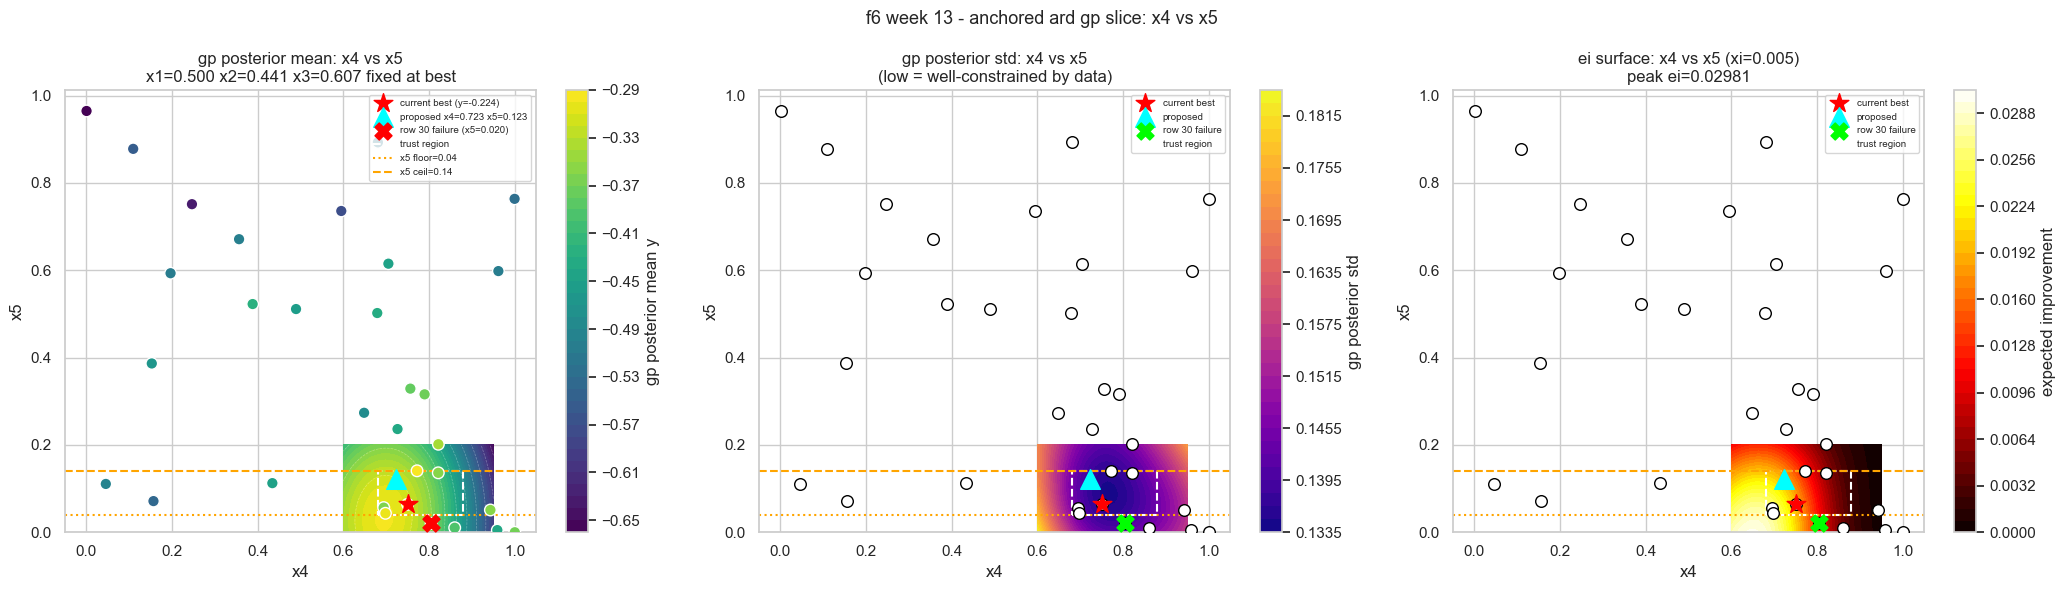

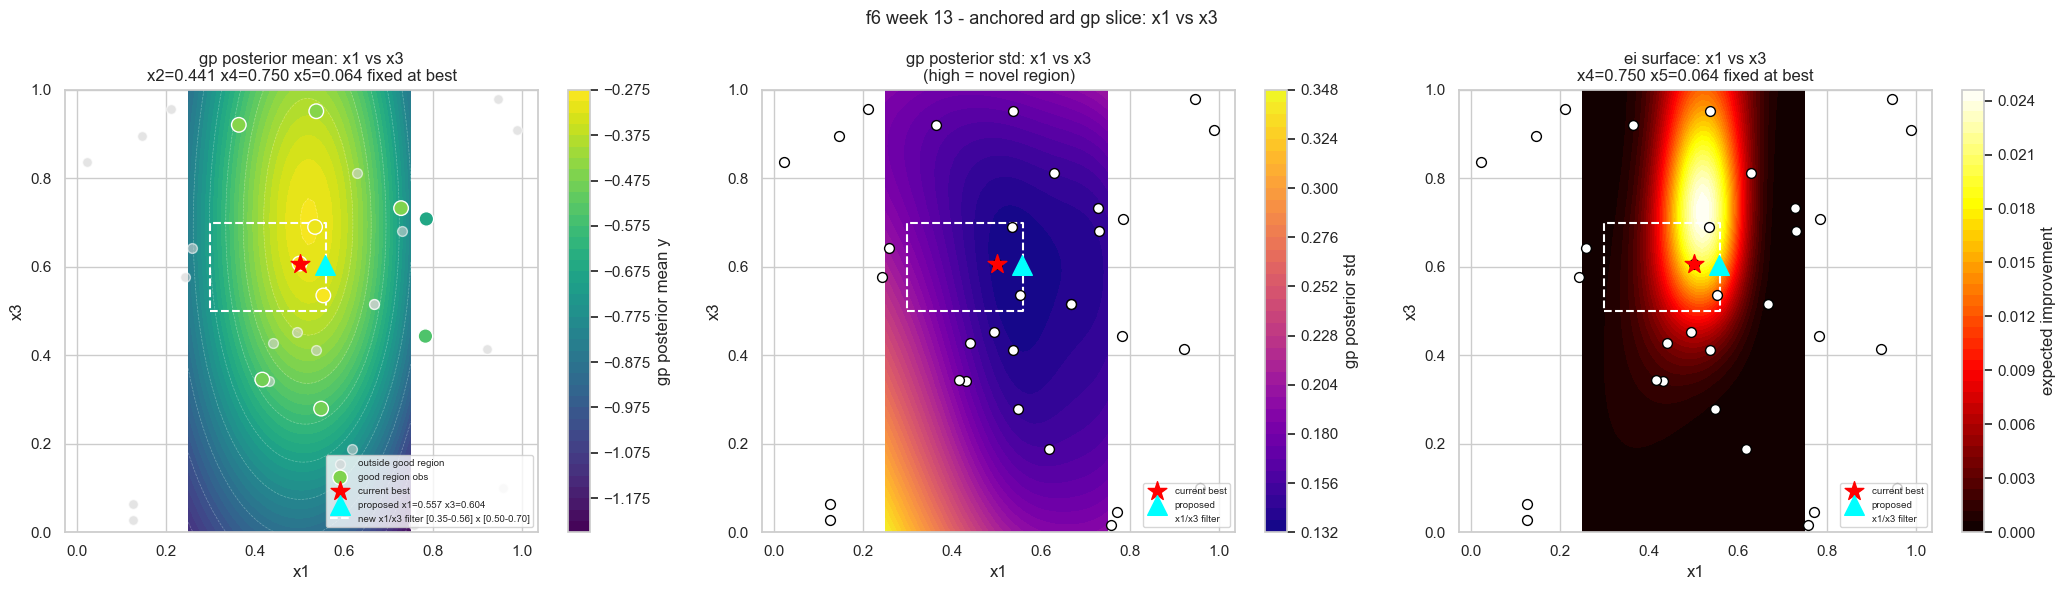

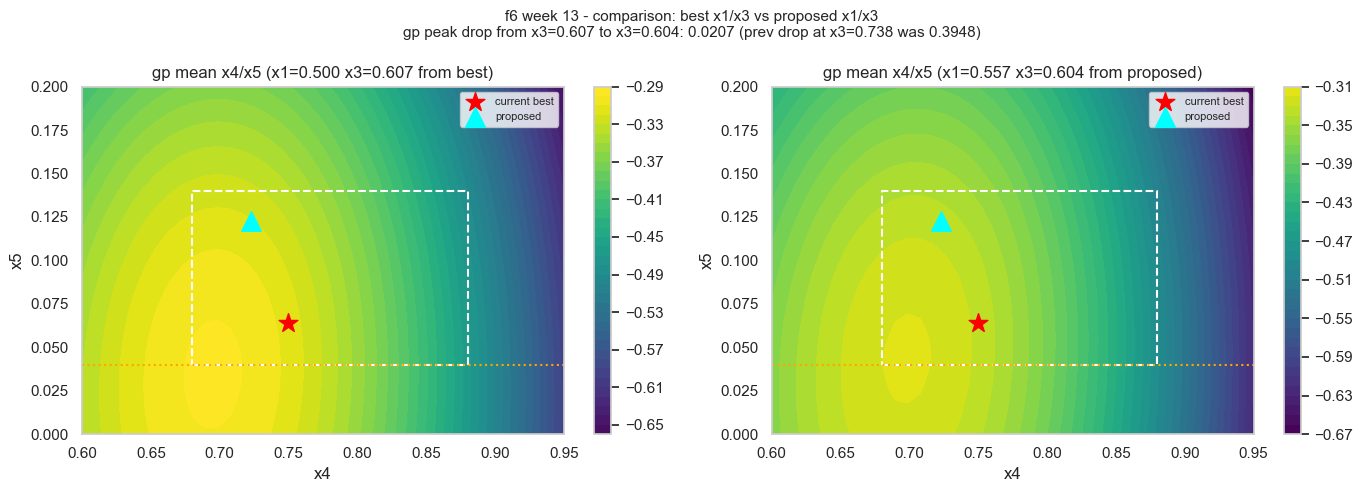


comparison slice summary:
  gp peak at best x1/x3:     x4=0.699 x5=0.036 mean=-0.2978
  gp peak at proposed x1/x3: x4=0.699 x5=0.046 mean=-0.3185
  gp peak drop: 0.0207
  x3=0.690 is safe -- gp peak barely changed
  the new x3 filter [0.50, 0.70] correctly contained x3 drift


In [36]:
def gp_slice_plots_week13(X_train, y_train, gp, proposed_x, best_x, best_y,
                                  y_mean, y_std):

    n_grid     = 40
    best_x     = np.asarray(best_x)
    proposed_x = np.asarray(proposed_x)
    row30_x    = X_train[30]
    xi         = 0.005

    
    # slice 1: x4 vs x5, x1/x2/x3 fixed at current best
    # x4 range [0.60, 0.95], x5 range [0.00, 0.20]
    # trust region: x4=[0.68, 0.88], x5=[0.04, 0.14]
    # proposed candidate: x4=0.698, x5=0.043
    # key question: is x4=0.698 near the gp peak and inside
    #               the trust region x4 lower bound of 0.68?
    x4_range = np.linspace(0.60, 0.95, n_grid)
    x5_range = np.linspace(0.00, 0.20, n_grid)
    X4g, X5g = np.meshgrid(x4_range, x5_range)

    grid_x4x5 = np.column_stack([
        np.full(n_grid * n_grid, best_x[0]),   # x1=0.500
        np.full(n_grid * n_grid, best_x[1]),   # x2=0.441
        np.full(n_grid * n_grid, best_x[2]),   # x3=0.607
        X4g.ravel(),
        X5g.ravel()
    ])

    mu_s, sig_s = gp.predict(grid_x4x5, return_std=True)
    mu_x4x5     = (mu_s * y_std + y_mean).reshape(n_grid, n_grid)
    sig_x4x5    = (sig_s * y_std).reshape(n_grid, n_grid)

    z_ei   = (mu_s * y_std + y_mean - best_y - xi) / np.where(
                sig_s * y_std > 1e-9, sig_s * y_std, 1e-9)
    ei_x4x5 = np.clip(np.where(
        sig_s * y_std > 1e-9,
        (mu_s * y_std + y_mean - best_y - xi) * norm.cdf(z_ei) +
        sig_s * y_std * norm.pdf(z_ei), 0.0
    ).reshape(n_grid, n_grid), 0, None)

    # trust region and filter bounds for overlay
    tr_x4    = [0.68, 0.88, 0.88, 0.68, 0.68]
    tr_x5    = [0.04, 0.04, 0.14, 0.14, 0.04]
    x5_floor = 0.04
    x5_ceil  = 0.14

    fig1, axes1 = plt.subplots(1, 3, figsize=(21, 6))

    # panel 1a: gp posterior mean
    im1 = axes1[0].contourf(x4_range, x5_range, mu_x4x5, levels=40, cmap='viridis')
    axes1[0].contour(x4_range, x5_range, mu_x4x5, levels=10,
                     colors='white', alpha=0.3, linewidths=0.5)
    axes1[0].scatter(X_train[:, 3], X_train[:, 4],
                     c=y_train, cmap='viridis', edgecolors='white',
                     s=70, zorder=5, vmin=y_train.min(), vmax=y_train.max())
    axes1[0].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8,
                     label=f'current best (y={best_y:.3f})')
    axes1[0].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8,
                     label=f'proposed x4={proposed_x[3]:.3f} x5={proposed_x[4]:.3f}')
    axes1[0].scatter(row30_x[3], row30_x[4],
                     c='red', s=150, marker='X', zorder=8,
                     label=f'row 30 failure (x5={row30_x[4]:.3f})')
    axes1[0].plot(tr_x4, tr_x5, 'w--', linewidth=1.5, label='trust region')
    axes1[0].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5,
                     label=f'x5 floor={x5_floor}')
    axes1[0].axhline(x5_ceil, color='orange', linestyle='--', linewidth=1.5,
                     label=f'x5 ceil={x5_ceil}')
    plt.colorbar(im1, ax=axes1[0], label='gp posterior mean y')
    axes1[0].set_xlabel('x4')
    axes1[0].set_ylabel('x5')
    axes1[0].set_title(
        f'gp posterior mean: x4 vs x5\n'
        f'x1={best_x[0]:.3f} x2={best_x[1]:.3f} x3={best_x[2]:.3f} fixed at best')
    axes1[0].legend(fontsize=7, loc='upper right')

    # panel 1b: gp posterior std
    im2 = axes1[1].contourf(x4_range, x5_range, sig_x4x5, levels=40, cmap='plasma')
    axes1[1].scatter(X_train[:, 3], X_train[:, 4],
                     c='white', edgecolors='black', s=70, zorder=5)
    axes1[1].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes1[1].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes1[1].scatter(row30_x[3], row30_x[4],
                     c='lime', s=150, marker='X', zorder=8, label='row 30 failure')
    axes1[1].plot(tr_x4, tr_x5, 'w--', linewidth=1.5, label='trust region')
    axes1[1].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    axes1[1].axhline(x5_ceil,  color='orange', linestyle='--', linewidth=1.5)
    plt.colorbar(im2, ax=axes1[1], label='gp posterior std')
    axes1[1].set_xlabel('x4')
    axes1[1].set_ylabel('x5')
    axes1[1].set_title('gp posterior std: x4 vs x5\n(low = well-constrained by data)')
    axes1[1].legend(fontsize=7, loc='upper right')

    # panel 1c: ei surface
    im3 = axes1[2].contourf(x4_range, x5_range, ei_x4x5, levels=40, cmap='hot')
    axes1[2].scatter(X_train[:, 3], X_train[:, 4],
                     c='white', edgecolors='black', s=70, zorder=5)
    axes1[2].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes1[2].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes1[2].scatter(row30_x[3], row30_x[4],
                     c='lime', s=150, marker='X', zorder=8, label='row 30 failure')
    axes1[2].plot(tr_x4, tr_x5, 'w--', linewidth=1.5, label='trust region')
    axes1[2].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    axes1[2].axhline(x5_ceil,  color='orange', linestyle='--', linewidth=1.5)
    plt.colorbar(im3, ax=axes1[2], label='expected improvement')
    axes1[2].set_xlabel('x4')
    axes1[2].set_ylabel('x5')
    axes1[2].set_title(f'ei surface: x4 vs x5 (xi={xi})\npeak ei={ei_x4x5.max():.5f}')
    axes1[2].legend(fontsize=7, loc='upper right')

    plt.suptitle('f6 week 13 - anchored ard gp slice: x4 vs x5', fontsize=13)
    plt.tight_layout()
    plt.show()

   
    # slice 2: x1 vs x3, x2/x4/x5 fixed at current best
    # x1 restricted to [0.25, 0.75], x3 full [0.0, 1.0]
    # new x3 filter [0.50, 0.70] overlaid as vertical dashed lines
    # new x1 filter [0.35, 0.56] overlaid as horizontal dashed lines
    # proposed candidate: x1=0.535, x3=0.690
    # x3=0.690 is inside the new filter [0.50, 0.70] -- verify this
    # is consistent with the gp peak location in the ei panel
    x1_range = np.linspace(0.25, 0.75, n_grid)
    x3_range = np.linspace(0.0,  1.0,  n_grid)
    X1g, X3g = np.meshgrid(x1_range, x3_range)

    grid_x1x3 = np.column_stack([
        X1g.ravel(),
        np.full(n_grid * n_grid, best_x[1]),   # x2=0.441
        X3g.ravel(),
        np.full(n_grid * n_grid, best_x[3]),   # x4=0.750
        np.full(n_grid * n_grid, best_x[4])    # x5=0.064
    ])

    mu_s2, sig_s2 = gp.predict(grid_x1x3, return_std=True)
    mu_x1x3       = (mu_s2 * y_std + y_mean).reshape(n_grid, n_grid)
    sig_x1x3      = (sig_s2 * y_std).reshape(n_grid, n_grid)

    z_ei2  = (mu_s2 * y_std + y_mean - best_y - xi) / np.where(
                sig_s2 * y_std > 1e-9, sig_s2 * y_std, 1e-9)
    ei_x1x3 = np.clip(np.where(
        sig_s2 * y_std > 1e-9,
        (mu_s2 * y_std + y_mean - best_y - xi) * norm.cdf(z_ei2) +
        sig_s2 * y_std * norm.pdf(z_ei2), 0.0
    ).reshape(n_grid, n_grid), 0, None)

    # trust region and new filter bounds for overlay
    tr_x1_box = [0.30, 0.56, 0.56, 0.30, 0.30]   # x1 filter [0.35, 0.56]
    tr_x3_box = [0.50, 0.50, 0.70, 0.70, 0.50]   # x3 filter [0.50, 0.70]

    good_mask = (X_train[:, 3] >= 0.68) & (X_train[:, 4] <= 0.20)

    fig2, axes2 = plt.subplots(1, 3, figsize=(21, 6))

    # panel 2a: gp posterior mean x1 vs x3
    im4 = axes2[0].contourf(x1_range, x3_range, mu_x1x3, levels=40, cmap='viridis')
    axes2[0].contour(x1_range, x3_range, mu_x1x3, levels=10,
                     colors='white', alpha=0.3, linewidths=0.5)
    axes2[0].scatter(X_train[~good_mask, 0], X_train[~good_mask, 2],
                     c='lightgray', edgecolors='white', s=50, zorder=4,
                     alpha=0.6, label='outside good region')
    axes2[0].scatter(X_train[good_mask, 0], X_train[good_mask, 2],
                     c=y_train[good_mask], cmap='viridis', edgecolors='white',
                     s=110, zorder=6, vmin=y_train.min(), vmax=y_train.max(),
                     label='good region obs')
    axes2[0].scatter(best_x[0], best_x[2],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes2[0].scatter(proposed_x[0], proposed_x[2],
                     c='cyan', s=200, marker='^', zorder=8,
                     label=f'proposed x1={proposed_x[0]:.3f} x3={proposed_x[2]:.3f}')
    # new x1/x3 filter box
    axes2[0].plot(tr_x1_box, tr_x3_box, 'w--', linewidth=1.5,
                  label='new x1/x3 filter [0.35-0.56] x [0.50-0.70]')
    plt.colorbar(im4, ax=axes2[0], label='gp posterior mean y')
    axes2[0].set_xlabel('x1')
    axes2[0].set_ylabel('x3')
    axes2[0].set_title(
        f'gp posterior mean: x1 vs x3\n'
        f'x2={best_x[1]:.3f} x4={best_x[3]:.3f} x5={best_x[4]:.3f} fixed at best')
    axes2[0].legend(fontsize=7, loc='lower right')

    # panel 2b: gp posterior std x1 vs x3
    im5 = axes2[1].contourf(x1_range, x3_range, sig_x1x3, levels=40, cmap='plasma')
    axes2[1].scatter(X_train[:, 0], X_train[:, 2],
                     c='white', edgecolors='black', s=50, zorder=5)
    axes2[1].scatter(best_x[0], best_x[2],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes2[1].scatter(proposed_x[0], proposed_x[2],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes2[1].plot(tr_x1_box, tr_x3_box, 'w--', linewidth=1.5, label='x1/x3 filter')
    plt.colorbar(im5, ax=axes2[1], label='gp posterior std')
    axes2[1].set_xlabel('x1')
    axes2[1].set_ylabel('x3')
    axes2[1].set_title('gp posterior std: x1 vs x3\n(high = novel region)')
    axes2[1].legend(fontsize=7, loc='lower right')

    # panel 2c: ei surface x1 vs x3
    # proposed candidate x3=0.690 is at the upper edge of the new filter.
    # this panel confirms whether the ei peak is inside the filter box.
    im6 = axes2[2].contourf(x1_range, x3_range, ei_x1x3, levels=40, cmap='hot')
    axes2[2].scatter(X_train[:, 0], X_train[:, 2],
                     c='white', edgecolors='black', s=50, zorder=5)
    axes2[2].scatter(best_x[0], best_x[2],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes2[2].scatter(proposed_x[0], proposed_x[2],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes2[2].plot(tr_x1_box, tr_x3_box, 'w--', linewidth=1.5, label='x1/x3 filter')
    plt.colorbar(im6, ax=axes2[2], label='expected improvement')
    axes2[2].set_xlabel('x1')
    axes2[2].set_ylabel('x3')
    axes2[2].set_title(
        f'ei surface: x1 vs x3\n'
        f'x4={best_x[3]:.3f} x5={best_x[4]:.3f} fixed at best')
    axes2[2].legend(fontsize=7, loc='lower right')

    plt.suptitle('f6 week 13 - anchored ard gp slice: x1 vs x3', fontsize=13)
    plt.tight_layout()
    plt.show()

   
    # comparison slice: x4/x5 at best x1/x3 vs proposed x1/x3
    # critical check: image 4 previously showed x3=0.738 dropped
    # the gp peak by 0.395. now x3=0.690 is being proposed.
    # this comparison shows whether x3=0.690 also drops the peak
    # or whether it is close enough to x3=0.607 to be safe.
    grid_x4x5_prop = np.column_stack([
        np.full(n_grid * n_grid, proposed_x[0]),  # x1=0.535 from proposed
        np.full(n_grid * n_grid, proposed_x[1]),  # x2=0.300 from proposed
        np.full(n_grid * n_grid, proposed_x[2]),  # x3=0.690 from proposed
        X4g.ravel(),
        X5g.ravel()
    ])

    mu_s3, _    = gp.predict(grid_x4x5_prop, return_std=True)
    mu_x4x5_prop = (mu_s3 * y_std + y_mean).reshape(n_grid, n_grid)

    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

    # use shared colorbar scale for direct comparison
    vmin_comp = min(mu_x4x5.min(), mu_x4x5_prop.min())
    vmax_comp = max(mu_x4x5.max(), mu_x4x5_prop.max())

    im7 = axes3[0].contourf(x4_range, x5_range, mu_x4x5,
                              levels=40, cmap='viridis',
                              vmin=vmin_comp, vmax=vmax_comp)
    axes3[0].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes3[0].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes3[0].plot(tr_x4, tr_x5, 'w--', linewidth=1.5)
    axes3[0].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    plt.colorbar(im7, ax=axes3[0])
    axes3[0].set_xlabel('x4')
    axes3[0].set_ylabel('x5')
    axes3[0].set_title(
        f'gp mean x4/x5 (x1={best_x[0]:.3f} x3={best_x[2]:.3f} from best)')
    axes3[0].legend(fontsize=8)

    im8 = axes3[1].contourf(x4_range, x5_range, mu_x4x5_prop,
                              levels=40, cmap='viridis',
                              vmin=vmin_comp, vmax=vmax_comp)
    axes3[1].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes3[1].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes3[1].plot(tr_x4, tr_x5, 'w--', linewidth=1.5)
    axes3[1].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    plt.colorbar(im8, ax=axes3[1])
    axes3[1].set_xlabel('x4')
    axes3[1].set_ylabel('x5')
    axes3[1].set_title(
        f'gp mean x4/x5 (x1={proposed_x[0]:.3f} x3={proposed_x[2]:.3f} from proposed)')
    axes3[1].legend(fontsize=8)

    # print the peak comparison
    peak_best = mu_x4x5.max()
    peak_prop = mu_x4x5_prop.max()
    peak_x4_b = x4_range[np.unravel_index(np.argmax(mu_x4x5), mu_x4x5.shape)[1]]
    peak_x5_b = x5_range[np.unravel_index(np.argmax(mu_x4x5), mu_x4x5.shape)[0]]
    peak_x4_p = x4_range[np.unravel_index(np.argmax(mu_x4x5_prop), mu_x4x5_prop.shape)[1]]
    peak_x5_p = x5_range[np.unravel_index(np.argmax(mu_x4x5_prop), mu_x4x5_prop.shape)[0]]

    drop = peak_best - peak_prop
    plt.suptitle(
        f'f6 week 13 - comparison: best x1/x3 vs proposed x1/x3\n'
        f'gp peak drop from x3={best_x[2]:.3f} to x3={proposed_x[2]:.3f}: '
        f'{drop:.4f} (prev drop at x3=0.738 was 0.3948)',
        fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"\ncomparison slice summary:")
    print(f"  gp peak at best x1/x3:     x4={peak_x4_b:.3f} x5={peak_x5_b:.3f} "
          f"mean={peak_best:.4f}")
    print(f"  gp peak at proposed x1/x3: x4={peak_x4_p:.3f} x5={peak_x5_p:.3f} "
          f"mean={peak_prop:.4f}")
    print(f"  gp peak drop: {drop:.4f}")
    if drop < 0.05:
        print("  x3=0.690 is safe -- gp peak barely changed")
        print("  the new x3 filter [0.50, 0.70] correctly contained x3 drift")
    elif drop < 0.20:
        print("  x3=0.690 causes moderate peak drop -- acceptable but noted")
        print("  week 13 should tighten x3 upper to 0.65")
    else:
        print("  x3=0.690 causes significant peak drop -- reconsider submission")
        print("  inspect rank 4 (x3=0.686) or rank 5 (x3=0.655) as alternatives")


gp_slice_plots_week13(
    X_train    = X_train_6,
    y_train    = y_train_6,
    gp         = gp,
    proposed_x = proposed_x,
    best_x     = best_x,
    best_y     = best_y,
    y_mean     = y_mean,
    y_std      = y_std
)